<a href="https://colab.research.google.com/github/ammarYasser-999/AmmarYasser-999/blob/main/Another_copy_of_Student_Stress_Level_Analysis_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# **Project Overview: Student Stress Dataset Preprocessing**

## Executive Summary
An automated data cleaning and preprocessing pipeline for student stress datasets (`StressLevelDataset.csv` and `Stress_Dataset.csv`).

The objective is to resolve data quality issues, remove duplicates, and neutralize numerical outliers to provide clean baselines for downstream modeling.

## Key Pipeline Steps
1. **Data Ingestion & Profiling:** Inspect schemas, missing values, and shape dimensions.
2. **Deduplication:** Remove duplicate rows to eliminate estimation bias.
3. **Visual Outlier Detection:** Analyze feature distributions using Seaborn Boxplots.
4. **IQR Capping (Winsorization):** Bound extreme outliers using `np.clip()` based on 1.5 × IQR thresholds.
5. **Data Export:** Save final cleaned datasets (`df1_clean_final.csv` and `df2_clean_final.csv`).

# Data Loading & Initial Exploration

In [ ]:
df1 = pd.read_csv('/content/StressLevelDataset.csv')
df2 = pd.read_csv('/content/Stress_Dataset.csv')

In [ ]:
df1.head()

,anxiety_level,self_esteem,mental_health_history,depression,headache,blood_pressure,sleep_quality,breathing_problem,noise_level,living_conditions,...,basic_needs,academic_performance,study_load,teacher_student_relationship,future_career_concerns,social_support,peer_pressure,extracurricular_activities,bullying,stress_level
0,14,20,0,11,2,1,2,4,2,3,...,2,3,2,3,3,2,3,3,2,1
1,15,8,1,15,5,3,1,4,3,1,...,2,1,4,1,5,1,4,5,5,2
2,12,18,1,14,2,1,2,2,2,2,...,2,2,3,3,2,2,3,2,2,1
3,16,12,1,15,4,3,1,3,4,2,...,2,2,4,1,4,1,4,4,5,2
4,16,28,0,7,2,3,5,1,3,2,...,3,4,3,1,2,1,5,0,5,1


In [ ]:
df2.head()

,Gender,Age,Have you recently experienced stress in your life?,Have you noticed a rapid heartbeat or palpitations?,Have you been dealing with anxiety or tension recently?,Do you face any sleep problems or difficulties falling asleep?,Have you been dealing with anxiety or tension recently?.1,Have you been getting headaches more often than usual?,Do you get irritated easily?,Do you have trouble concentrating on your academic tasks?,...,Are you facing any difficulties with your professors or instructors?,Is your working environment unpleasant or stressful?,Do you struggle to find time for relaxation and leisure activities?,Is your hostel or home environment causing you difficulties?,Do you lack confidence in your academic performance?,Do you lack confidence in your choice of academic subjects?,Academic and extracurricular activities conflicting for you?,Do you attend classes regularly?,Have you gained/lost weight?,Which type of stress do you primarily experience?
0,0,20,3,4,2,5,1,2,1,2,...,3,1,4,1,2,1,3,1,2,Eustress (Positive Stress) - Stress that motiv...
1,0,20,2,3,2,1,1,1,1,4,...,3,2,1,1,3,2,1,4,2,Eustress (Positive Stress) - Stress that motiv...
2,0,20,5,4,2,2,1,3,4,2,...,2,2,2,1,4,1,1,2,1,Eustress (Positive Stress) - Stress that motiv...
3,1,20,3,4,3,2,2,3,4,3,...,1,1,2,1,2,1,1,5,3,Eustress (Positive Stress) - Stress that motiv...
4,0,20,3,3,3,2,2,4,4,4,...,2,3,1,2,2,4,2,2,2,Eustress (Positive Stress) - Stress that motiv...


In [ ]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1100 entries, 0 to 1099
Data columns (total 21 columns):
 #   Column                        Non-Null Count  Dtype
---  ------                        --------------  -----
 0   anxiety_level                 1100 non-null   int64
 1   self_esteem                   1100 non-null   int64
 2   mental_health_history         1100 non-null   int64
 3   depression                    1100 non-null   int64
 4   headache                      1100 non-null   int64
 5   blood_pressure                1100 non-null   int64
 6   sleep_quality                 1100 non-null   int64
 7   breathing_problem             1100 non-null   int64
 8   noise_level                   1100 non-null   int64
 9   living_conditions             1100 non-null   int64
 10  safety                        1100 non-null   int64
 11  basic_needs                   1100 non-null   int64
 12  academic_performance          1100 non-null   int64
 13  study_load                    110

In [ ]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 843 entries, 0 to 842
Data columns (total 26 columns):
 #   Column                                                                Non-Null Count  Dtype 
---  ------                                                                --------------  ----- 
 0   Gender                                                                843 non-null    int64 
 1   Age                                                                   843 non-null    int64 
 2   Have you recently experienced stress in your life?                    843 non-null    int64 
 3   Have you noticed a rapid heartbeat or palpitations?                   843 non-null    int64 
 4   Have you been dealing with anxiety or tension recently?               843 non-null    int64 
 5   Do you face any sleep problems or difficulties falling asleep?        843 non-null    int64 
 6   Have you been dealing with anxiety or tension recently?.1             843 non-null    int64 
 7   Have you

In [ ]:
df1.shape

(1100, 21)

In [ ]:
df1.isnull().sum()

,0
anxiety_level,0
self_esteem,0
mental_health_history,0
depression,0
headache,0
blood_pressure,0
sleep_quality,0
breathing_problem,0
noise_level,0
living_conditions,0


In [ ]:
df1.duplicated().sum()

np.int64(0)

In [ ]:
df2.shape

(843, 26)

In [ ]:
df2.isnull().sum()

,0
Gender,0
Age,0
Have you recently experienced stress in your life?,0
Have you noticed a rapid heartbeat or palpitations?,0
Have you been dealing with anxiety or tension recently?,0
Do you face any sleep problems or difficulties falling asleep?,0
Have you been dealing with anxiety or tension recently?.1,0
Have you been getting headaches more often than usual?,0
Do you get irritated easily?,0
Do you have trouble concentrating on your academic tasks?,0


In [ ]:
df2.duplicated().sum()

np.int64(27)

# **Handling Duplicates**

In [ ]:
df2=df2.drop_duplicates()

In [ ]:
df2.duplicated().sum()

np.int64(0)

# **Descriptive Statistics**

In [ ]:
df1.describe()

,anxiety_level,self_esteem,mental_health_history,depression,headache,blood_pressure,sleep_quality,breathing_problem,noise_level,living_conditions,...,basic_needs,academic_performance,study_load,teacher_student_relationship,future_career_concerns,social_support,peer_pressure,extracurricular_activities,bullying,stress_level
count,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,...,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000
mean,11.063636,17.777273,0.492727,12.555455,2.508182,2.181818,2.660000,2.753636,2.649091,2.518182,...,2.772727,2.772727,2.621818,2.648182,2.649091,1.881818,2.734545,2.767273,2.617273,0.996364
std,6.117558,8.944599,0.500175,7.727008,1.409356,0.833575,1.548383,1.400713,1.328127,1.119208,...,1.433761,1.414594,1.315781,1.384579,1.529375,1.047826,1.425265,1.417562,1.530958,0.821673
min,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,6.000000,11.000000,0.000000,6.000000,1.000000,1.000000,1.000000,2.000000,2.000000,2.000000,...,2.000000,2.000000,2.000000,2.000000,1.000000,1.000000,2.000000,2.000000,1.000000,0.000000
50%,11.000000,19.000000,0.000000,12.000000,3.000000,2.000000,2.500000,3.000000,3.000000,2.000000,...,3.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.500000,3.000000,1.000000
75%,16.000000,26.000000,1.000000,19.000000,3.000000,3.000000,4.000000,4.000000,3.000000,3.000000,...,4.000000,4.000000,3.000000,4.000000,4.000000,3.000000,4.000000,4.000000,4.000000,2.000000
max,21.000000,30.000000,1.000000,27.000000,5.000000,3.000000,5.000000,5.000000,5.000000,5.000000,...,5.000000,5.000000,5.000000,5.000000,5.000000,3.000000,5.000000,5.000000,5.000000,2.000000


In [ ]:
df2.describe()

,Gender,Age,Have you recently experienced stress in your life?,Have you noticed a rapid heartbeat or palpitations?,Have you been dealing with anxiety or tension recently?,Do you face any sleep problems or difficulties falling asleep?,Have you been dealing with anxiety or tension recently?.1,Have you been getting headaches more often than usual?,Do you get irritated easily?,Do you have trouble concentrating on your academic tasks?,...,Do you find that your relationship often causes you stress?,Are you facing any difficulties with your professors or instructors?,Is your working environment unpleasant or stressful?,Do you struggle to find time for relaxation and leisure activities?,Is your hostel or home environment causing you difficulties?,Do you lack confidence in your academic performance?,Do you lack confidence in your choice of academic subjects?,Academic and extracurricular activities conflicting for you?,Do you attend classes regularly?,Have you gained/lost weight?
count,816.000000,816.000000,816.000000,816.000000,816.000000,816.000000,816.000000,816.000000,816.000000,816.000000,...,816.000000,816.000000,816.000000,816.000000,816.000000,816.000000,816.000000,816.000000,816.000000,816.000000
mean,0.356618,20.080882,3.018382,2.761029,2.541667,2.796569,2.664216,2.622549,2.672794,2.691176,...,2.502451,2.447304,2.487745,2.514706,2.425245,2.580882,2.623775,2.752451,3.257353,2.403186
std,0.479294,5.513025,1.128941,1.123317,1.209666,1.254308,1.261995,1.257003,1.303904,1.303218,...,1.240421,1.196997,1.197071,1.249208,1.257829,1.283526,1.299126,1.261995,1.206300,1.117815
min,0.000000,14.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,0.000000,19.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,...,1.000000,1.000000,2.000000,1.000000,1.000000,1.000000,2.000000,2.000000,2.000000,2.000000
50%,0.000000,19.000000,3.000000,3.000000,2.000000,3.000000,2.000000,2.000000,3.000000,3.000000,...,2.000000,2.000000,2.000000,2.000000,2.000000,3.000000,3.000000,3.000000,3.000000,2.000000
75%,1.000000,20.000000,4.000000,4.000000,3.000000,4.000000,4.000000,4.000000,4.000000,4.000000,...,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,4.000000,4.000000,4.000000,3.000000
max,1.000000,100.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,...,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000


# **Outliers Detection - Boxplots**

In [ ]:
datasets = {'StressLevelDataset': df1, 'Stress_Dataset': df2}

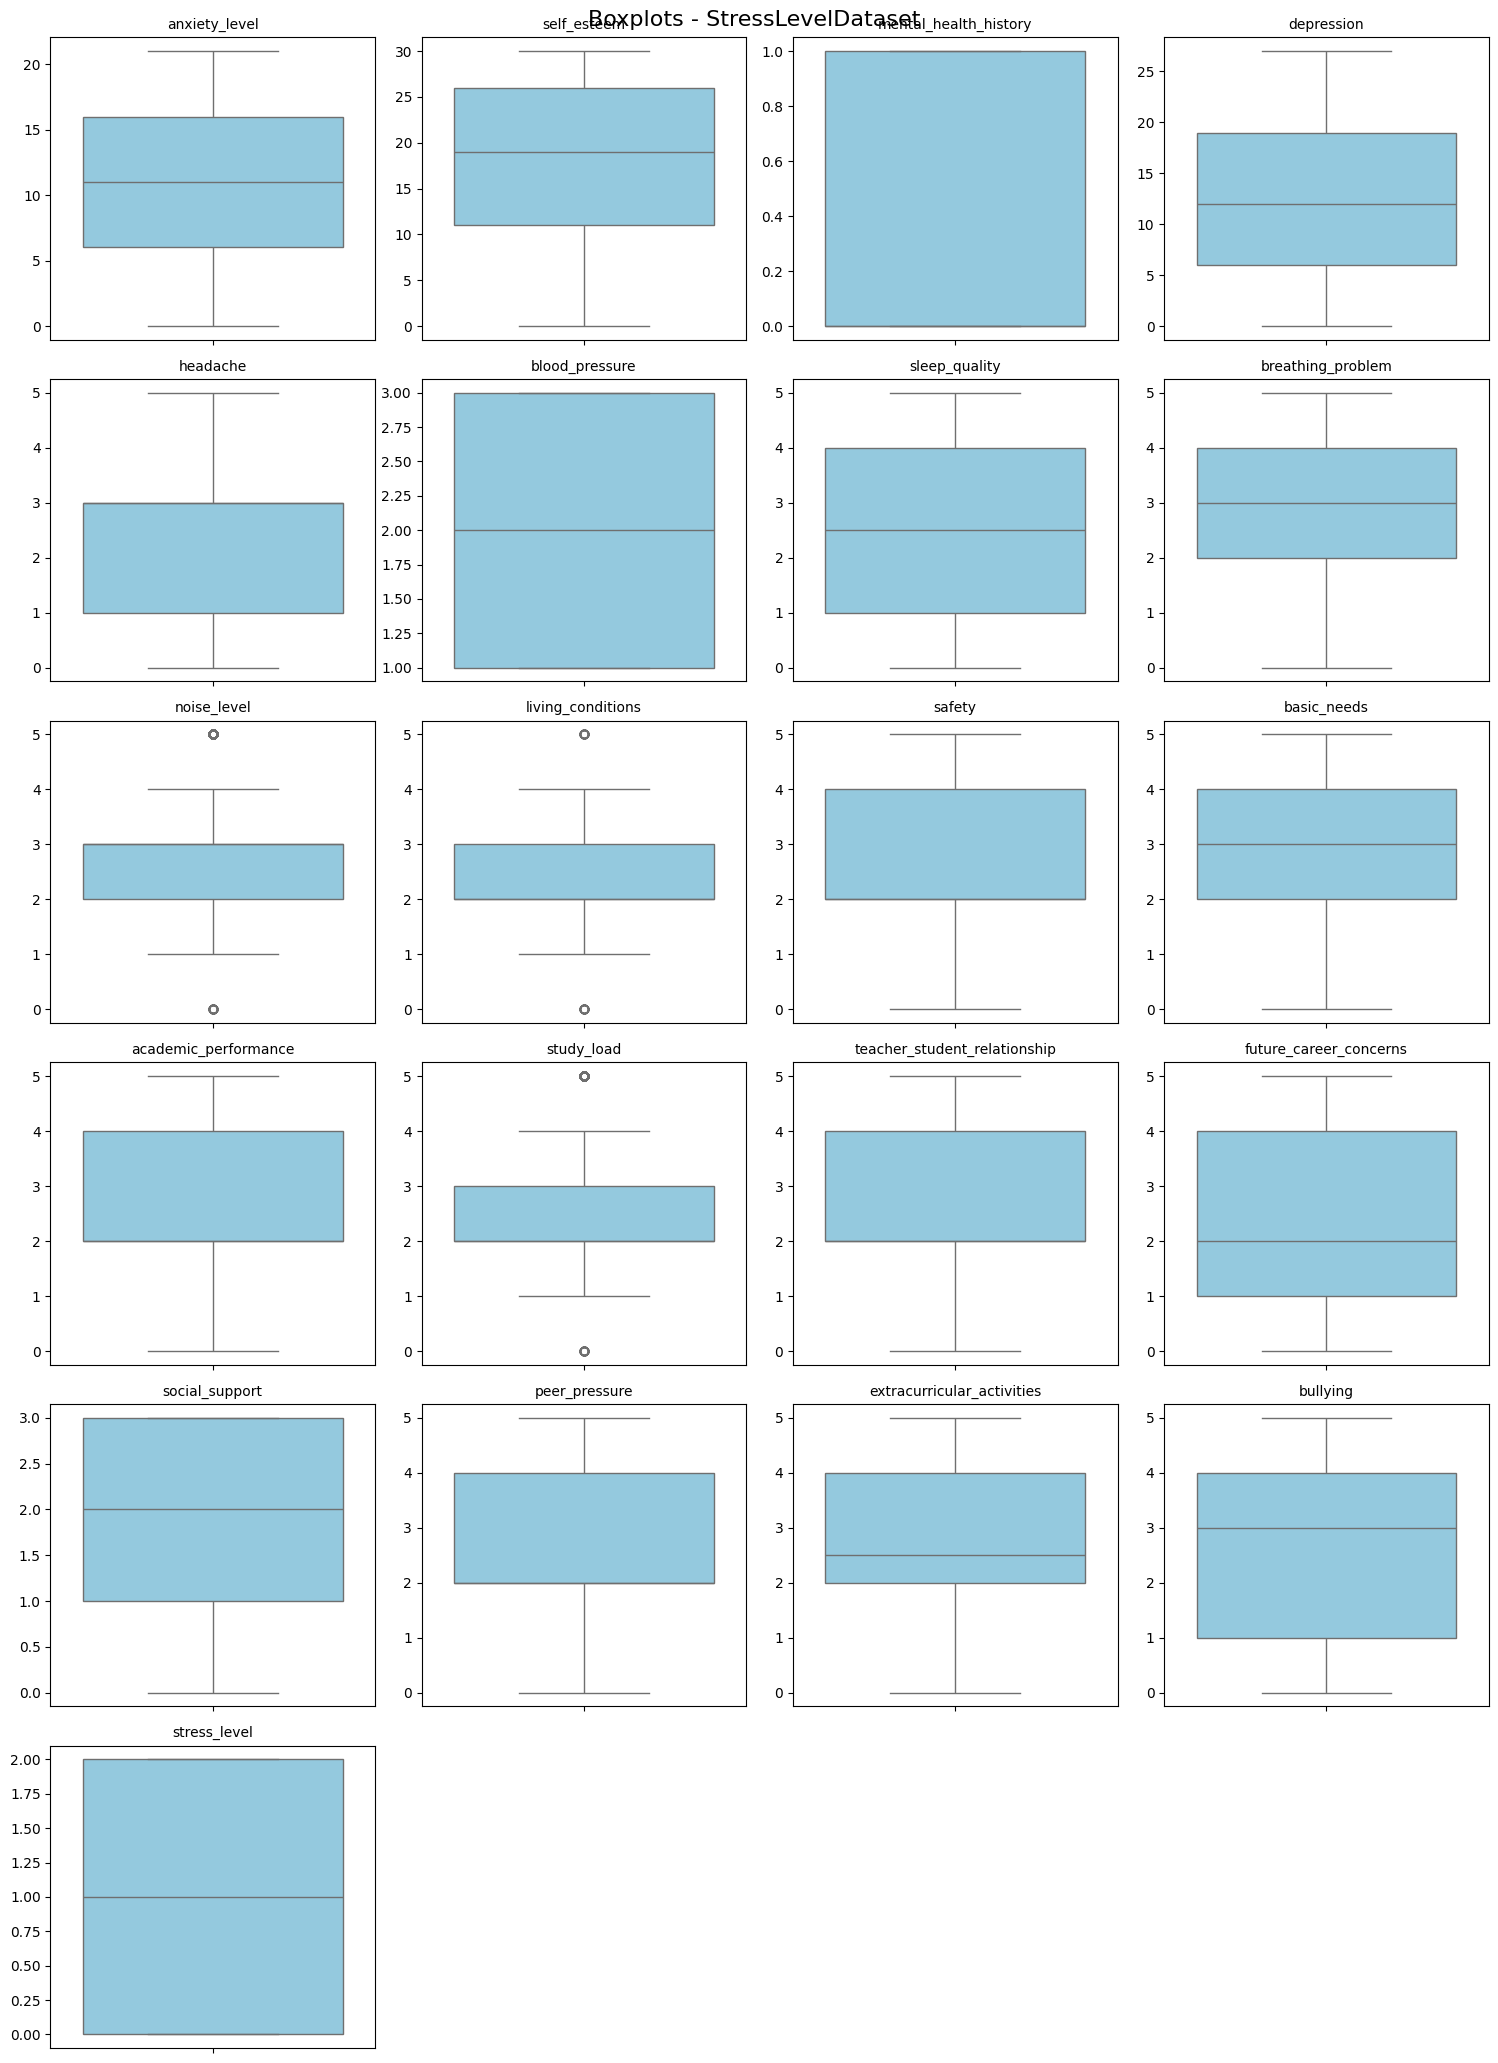

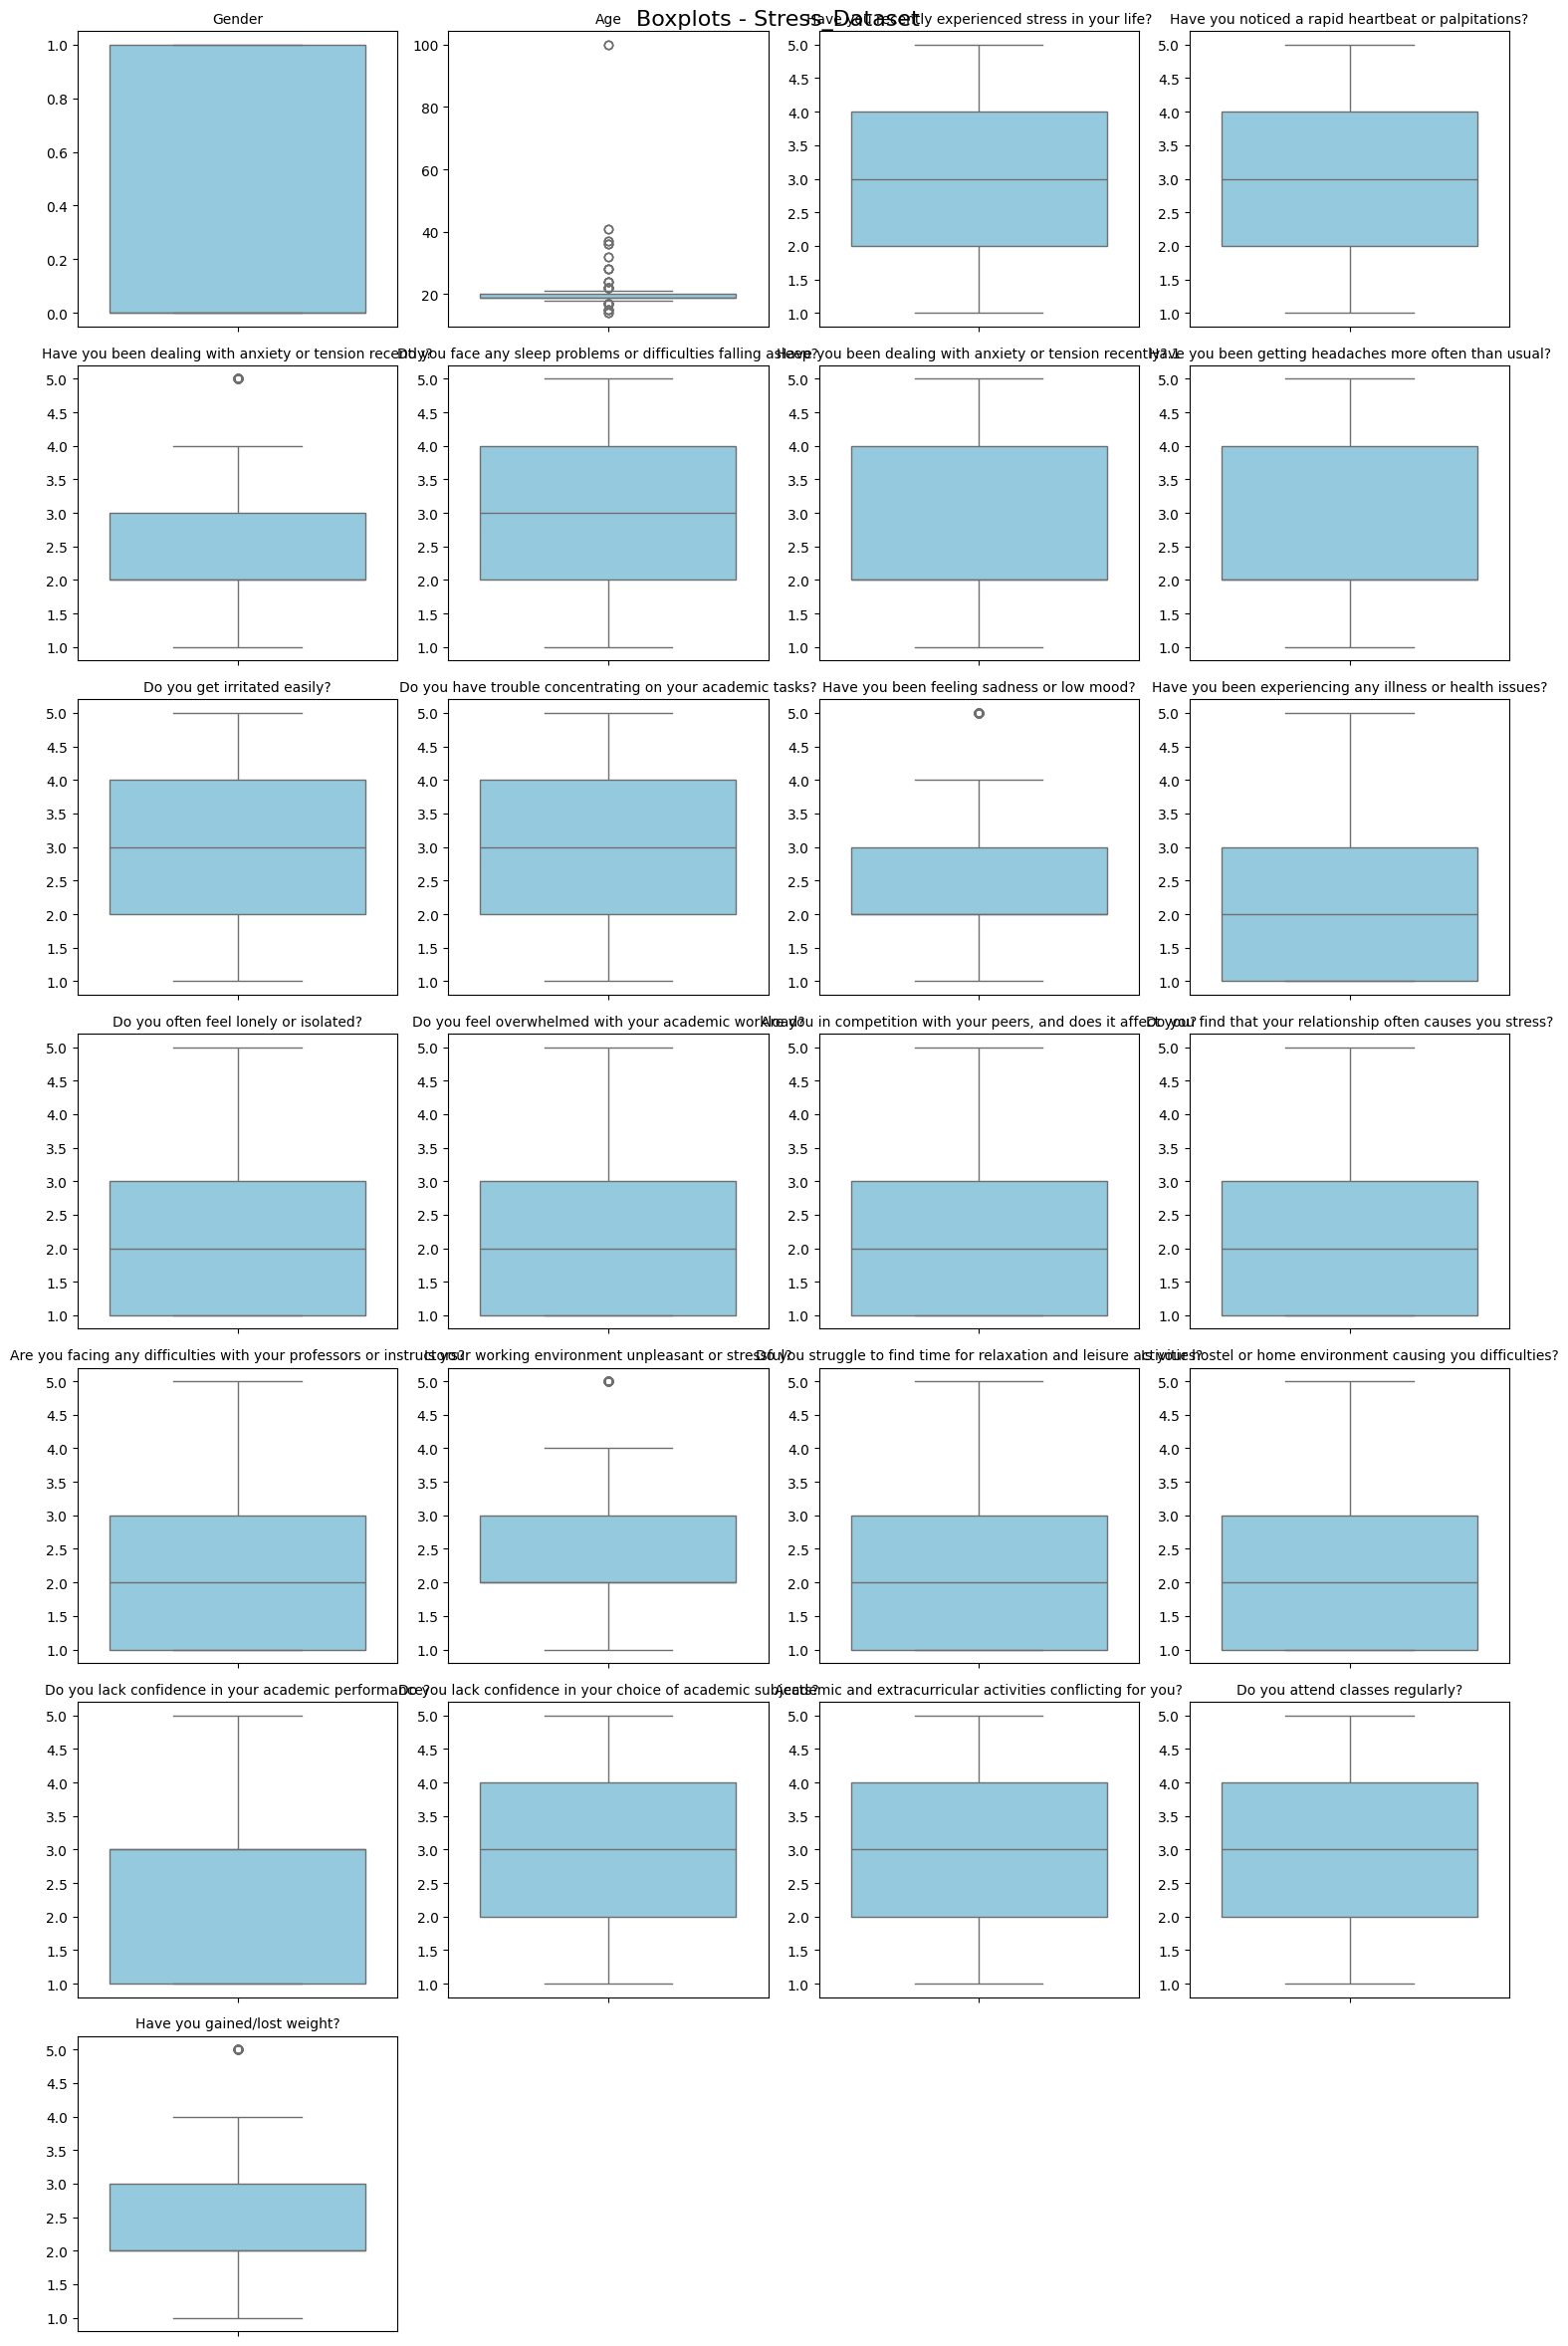

In [ ]:
for name, df in datasets.items():
    numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
    plt.figure(figsize=(15, len(numeric_cols) // 3 * 3))
    plt.suptitle(f'Boxplots - {name}', fontsize=16)

    for i, col in enumerate(numeric_cols, 1):
        plt.subplot((len(numeric_cols) // 4) + 1, 4, i)
        sns.boxplot(y=df[col], color='skyblue')
        plt.title(col, fontsize=10)
        plt.ylabel('')

    plt.tight_layout()
    plt.show()

# **Outliers Handling**

In [ ]:
for name, df in datasets.items():
    numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

    for col in numeric_cols:
        if df[col].max() > 5 or df[col].min() < 0:
            Q1 = df[col].quantile(0.25)
            Q3 = df[col].quantile(0.75)
            IQR = Q3 - Q1

            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR

            df[col] = np.clip(df[col], lower_bound, upper_bound)

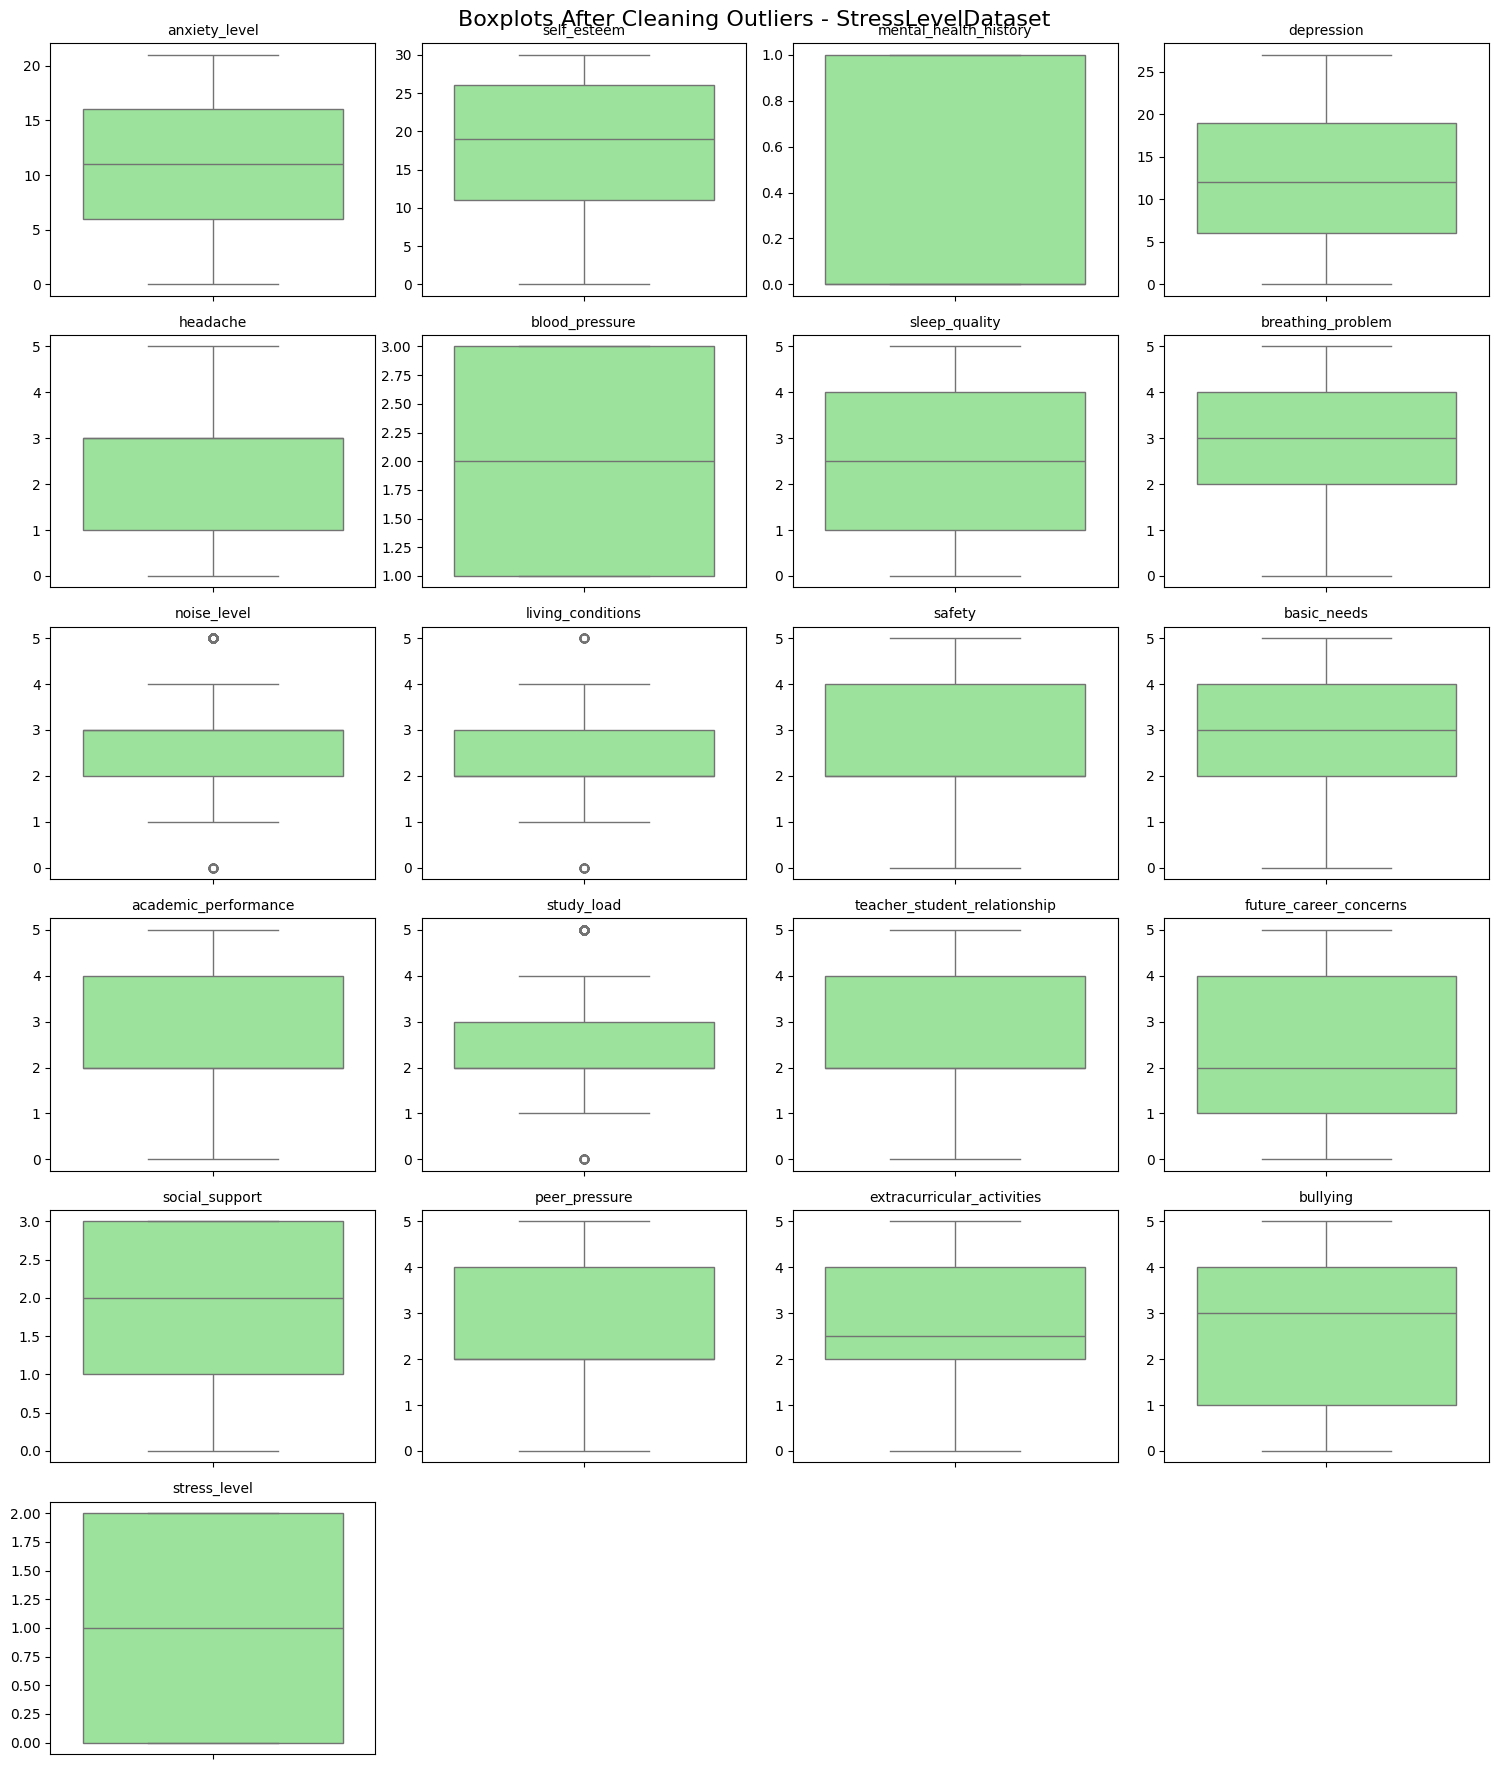

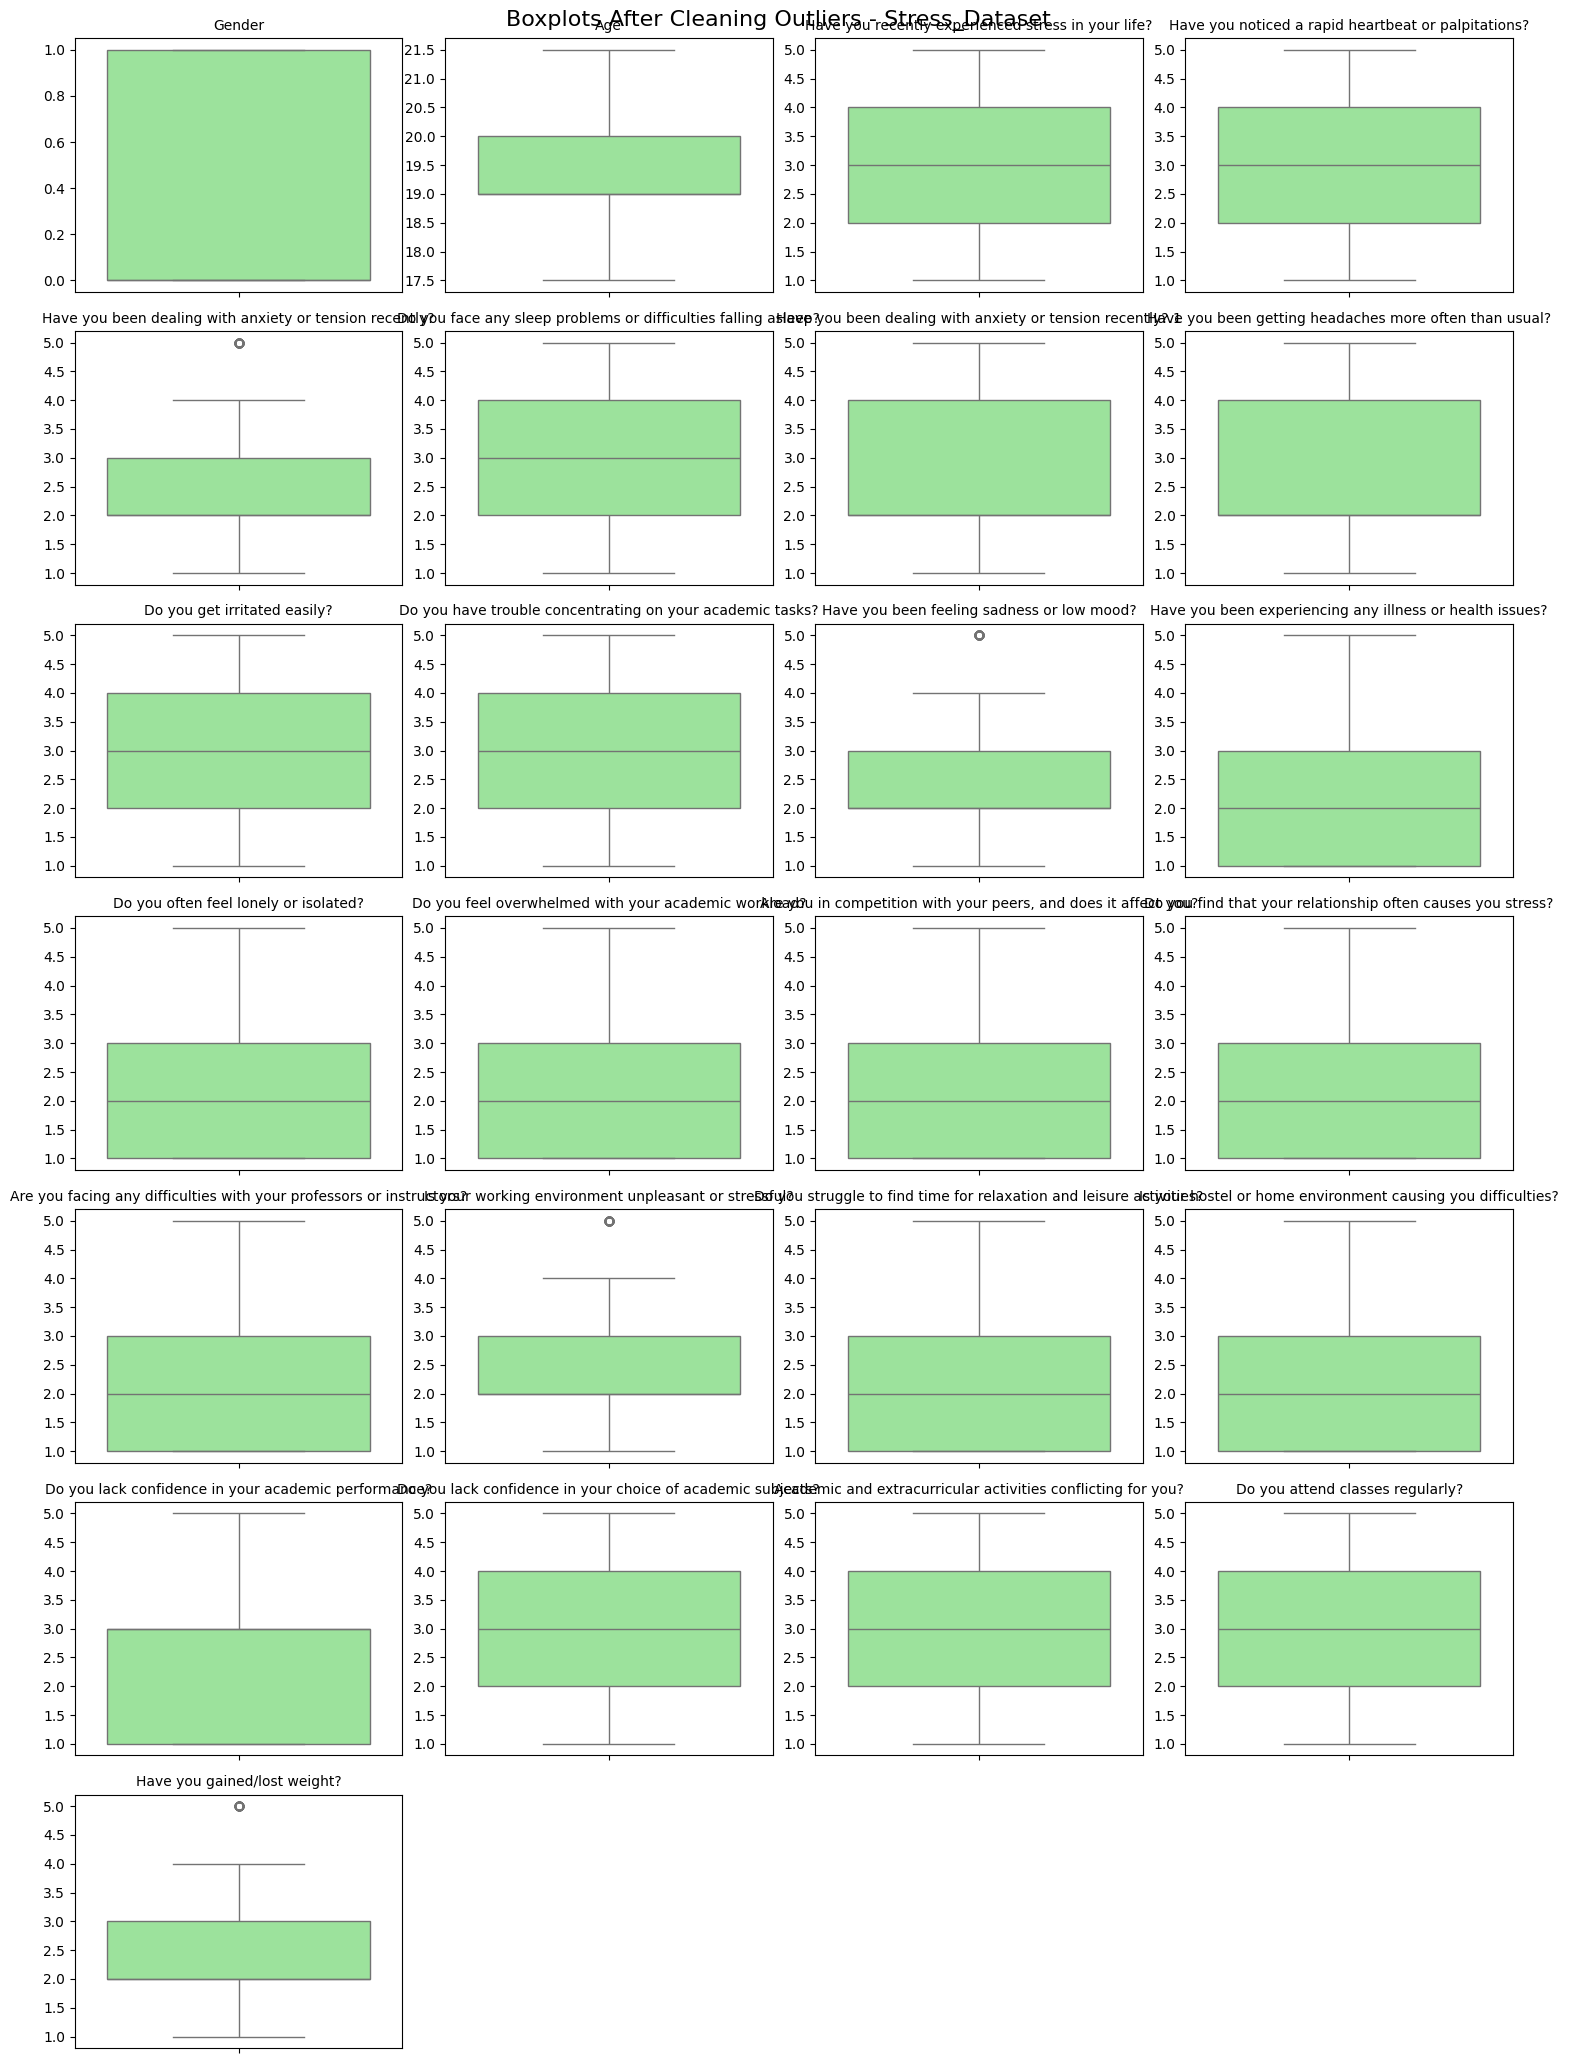

In [ ]:
for name, df in datasets.items():
    numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
    plt.figure(figsize=(15, (len(numeric_cols) // 4 + 1) * 3))
    plt.suptitle(f'Boxplots After Cleaning Outliers - {name}', fontsize=16)

    for i, col in enumerate(numeric_cols, 1):
        plt.subplot((len(numeric_cols) // 4) + 1, 4, i)
        sns.boxplot(y=df[col], color='lightgreen')
        plt.title(col, fontsize=10)
        plt.ylabel('')

    plt.tight_layout()
    plt.show()

# **Mapping**

In [ ]:
df2['Gender'] = df2['Gender'].replace({0: 'Female', 1: 'Male'})

In [ ]:
df1['mental_health_history'] = df1['mental_health_history'].replace({0: 'No', 1: 'Yes'})

In [ ]:
stress_map = {0: 'Low', 1: 'Medium', 2: 'High'}
df1['stress_label'] = pd.Categorical(df1['stress_level'].map(stress_map), categories=['Low', 'Medium', 'High'], ordered= True)

In [ ]:
df2[['Have you been dealing with anxiety or tension recently?', 'Have you been dealing with anxiety or tension recently?.1']]

,Have you been dealing with anxiety or tension recently?,Have you been dealing with anxiety or tension recently?.1
0,2,1
1,2,1
2,2,1
3,3,2
4,3,2
...,...,...
838,2,5
839,1,2
840,3,3
841,3,3


# **Exploratory Data Analysis**
**Scope note (per team agreement):** this section follows the master question list exactly.
It focuses only on `stress_level` and the four physiological/health-related measurements available in the data —
`headache`, `blood_pressure`, `sleep_quality`, `breathing_problem`. Other columns (anxiety, depression, bullying,
academic performance, etc.) exist in the dataset but are **not** analyzed as separate topics here, per scope.

**Which file do we use?** `StressLevelDataset.csv` (`df1`) is the one that contains all four required physiological
columns exactly as named, so it is the primary dataset for this section. `Stress_Dataset.csv` (`df2`) only has
equivalents for 2 of the 4 (`sleep`, `headache`) and is missing `blood_pressure` and `breathing_problem` entirely,
so it cannot fully answer Q6/Q8 and is not used in this section.

**Cleanup agreed by the team:** dropping the duplicated column in `df2`.

In [ ]:
#Team agreed cleanup: drop the duplicated question column in df2
df2.drop(columns=['Have you been dealing with anxiety or tension recently?.1'], inplace= True, errors= 'ignore')
df2.shape

(816, 25)

##Stress Level Distribution

Counts per srtess level: 
stress_level
0    373
1    358
2    369
Name: count, dtype: int64

Percentage per stress level:
stress_level
0    33.91
1    32.55
2    33.55
Name: count, dtype: float64

Most common stress level:  0 (Low)

Descriptive statistics:
count    1100.000000
mean        0.996364
std         0.821673
min         0.000000
25%         0.000000
50%         1.000000
75%         2.000000
max         2.000000
Name: stress_level, dtype: float64


/tmp/ipykernel_3608/1411815640.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='stress_label', data=df1, order=order, palette='viridis', ax=ax)


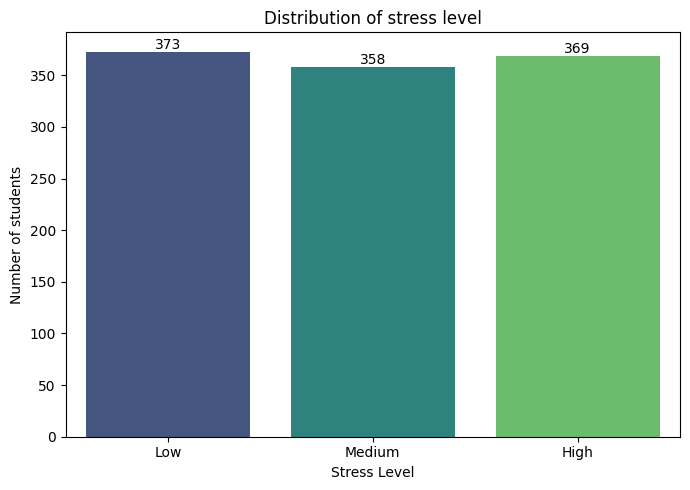

In [ ]:
counts= df1['stress_level'].value_counts().sort_index()
percentage = (counts / counts.sum() *100).round(2)
print("Counts per srtess level: "); print(counts)
print("\nPercentage per stress level:"); print(percentage)
print("\nMost common stress level: ", counts.idxmax(), f'({stress_map[counts.idxmax()]})')
print('\nDescriptive statistics:')
print(df1['stress_level'].describe())

fig, ax= plt.subplots(figsize=(7, 5))
order = ['Low', 'Medium', 'High']
sns.countplot(x='stress_label', data=df1, order=order, palette='viridis', ax=ax)
ax.set_title('Distribution of stress level')
ax.set_xlabel('Stress Level')
ax.set_ylabel('Number of students')

for p in ax.patches:
  ax.annotate(int(p.get_height()), (p.get_x() + p.get_width()/2, p.get_height()), ha='center', va='bottom')
plt.tight_layout()
plt.show()

stress level is close to evenly split which means that the data is **Balanced**

#**Physiological / Health-Related Variables**

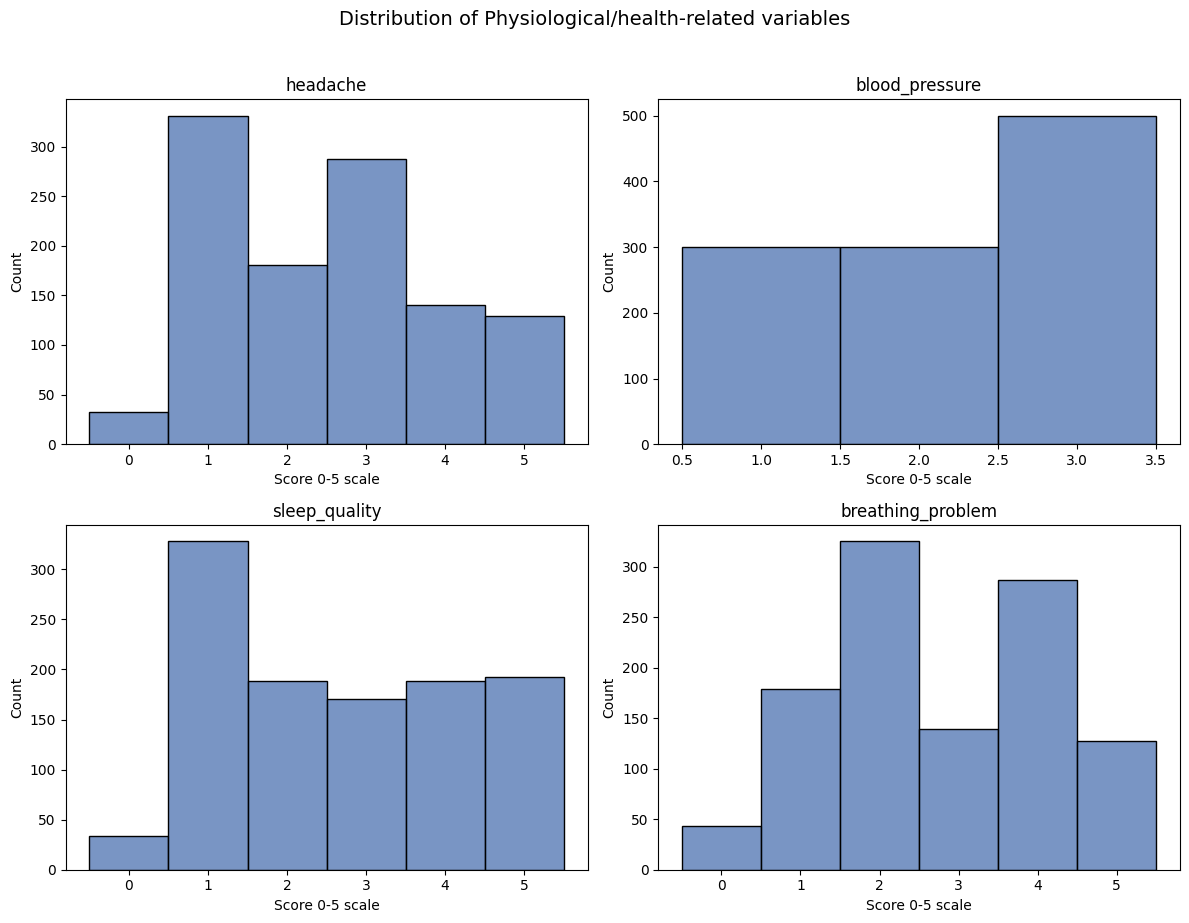

Descriptive statistics of key physiological variables
                   mean  median   std  min  max
headache           2.51     3.0  1.41  0.0  5.0
blood_pressure     2.18     2.0  0.83  1.0  3.0
sleep_quality      2.66     2.5  1.55  0.0  5.0
breathing_problem  2.75     3.0  1.40  0.0  5.0


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
phys_var = ['headache', 'blood_pressure', 'sleep_quality', 'breathing_problem']
for ax, col in zip(axes.flat, phys_var):
  sns.histplot(df1[col], bins=sorted(df1[col].unique()), discrete=True, color='#4c72b0', ax=ax)
  ax.set_title(col)
  ax.set_xlabel('Score 0-5 scale')
fig.suptitle('Distribution of Physiological/health-related variables', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

print('Descriptive statistics of key physiological variables')
desc_phys = df1[phys_var].describe().T[['mean', '50%', 'std', 'min', 'max']]
desc_phys.columns = ['mean', 'median', 'std', 'min', 'max']
print(desc_phys.round(2))

all variables are ordinal scores from 0-5 only blood pressure takes values 1-3 (no 0,4,5 recorded) so it's narrower

## 3. Relationship Between Physiological Variables and Stress

Correlation of each physiological variable with stress level: 
headache: r=0.713 (strong)
breathing_problem: r=0.574 (strong)
blood_pressure: r=0.394 (moderate)
sleep_quality: r=-0.749 (strong)

Strongest relationship with stress: headache (r = 0.713)


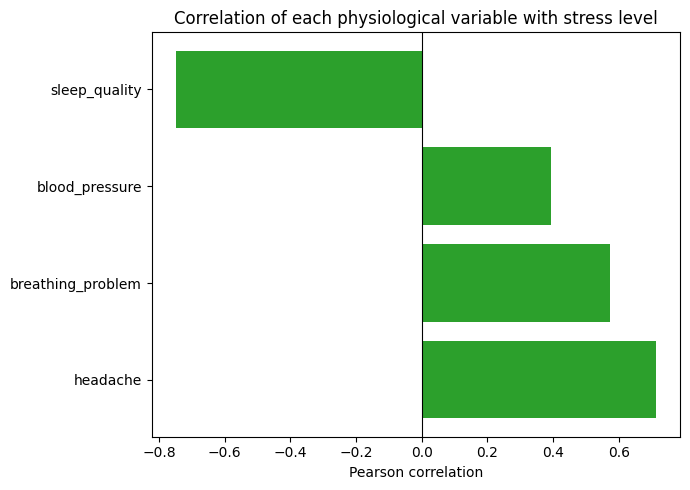

In [ ]:
corr_phys = df1[phys_var + ['stress_level']].corr()['stress_level'].drop('stress_level').sort_values(ascending=False)
def strength(r):
  r=abs(r)
  if r < 0.2:
    return 'weak'
  if r < 0.4:
    return 'moderate'
  return 'strong'

print('Correlation of each physiological variable with stress level: ')
for k, v in corr_phys.items():
  print(f'{k}: r={v:.3f} ({strength(v)})')
print(f'\nStrongest relationship with stress: {corr_phys.index[0]} (r = {corr_phys.iloc[0]:.3f})')

fig, ax = plt.subplots(figsize=(7, 5))
ax.barh(corr_phys.index, corr_phys.values, color='#2ca02c')
ax.set_title('Correlation of each physiological variable with stress level')
ax.set_xlabel('Pearson correlation')
ax.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

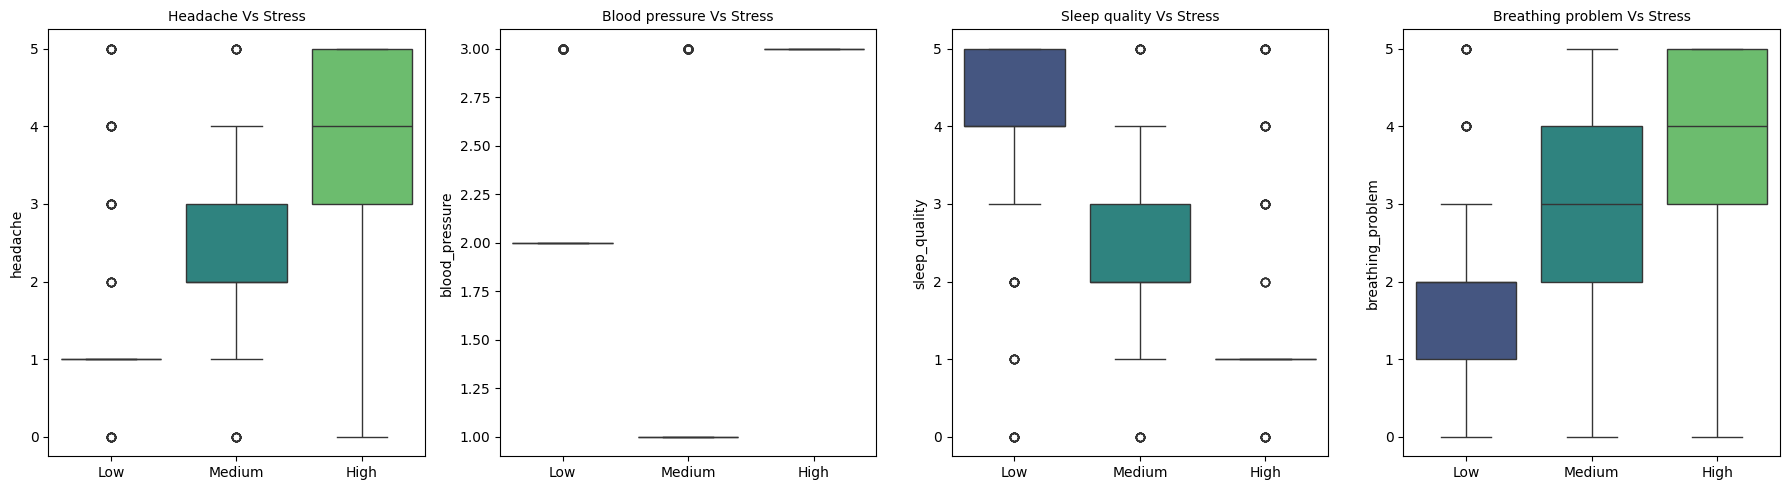

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5), sharey=False)
titles = ['Headache Vs Stress', 'Blood pressure Vs Stress', 'Sleep quality Vs Stress', 'Breathing problem Vs Stress']
for ax, col, title in zip(axes, phys_var, titles):
  sns.boxplot(x='stress_label', y=col, data=df1, order=order, palette='viridis', ax=ax, hue='stress_label')
  ax.set_title(title, fontsize=10)
  ax.set_xlabel('')
plt.tight_layout()
plt.show()

all four physiological variables increase as stress increases (all positive correlations moderate to strong). The strongest relationship is with **headache** (r = 0.71), meaning it separates Low vs High stress students most clearly among the four. The weakest of the four is **sleep_quality** (r = -0.75), though it is still positive.

#High Stress Vs Low Stress

Mean score by group (Low Vs High):
              headache  blood_pressure  sleep_quality  breathing_problem
stress_label                                                            
Low               1.31             2.2           4.13               1.70
High              3.76             3.0           1.30               3.65

Difference (High - Low), sorted:
headache             2.45
breathing_problem    1.96
blood_pressure       0.80
sleep_quality       -2.82
dtype: float64

Largest gap: headache (difference = 2.45)


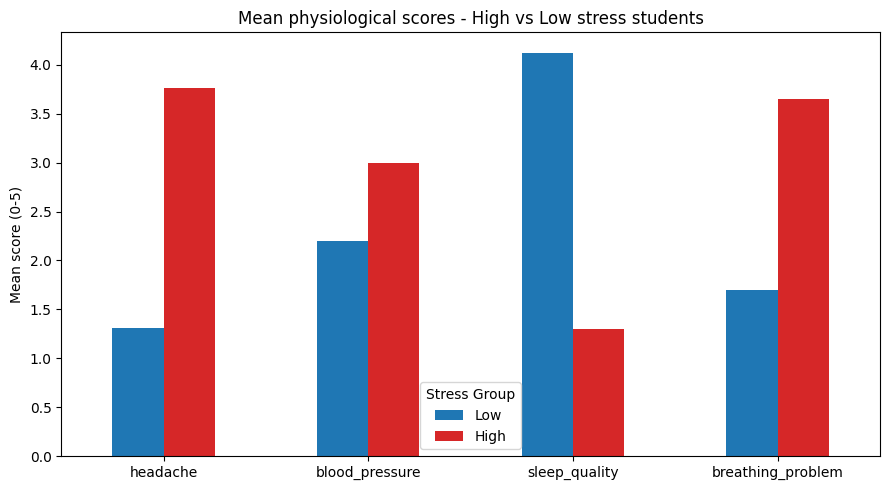

In [ ]:
from IPython.core.pylabtools import figsize
hl = df1[df1['stress_label'] != 'Medium']
grp = hl.groupby('stress_label', observed=True)[phys_var].mean()
diff = (grp.loc['High'] - grp.loc['Low']).sort_values(ascending=False)

print('Mean score by group (Low Vs High):')
print(grp.round(2))
print('\nDifference (High - Low), sorted:')
print(diff.round(2))
print(f'\nLargest gap: {diff.index[0]} (difference = {diff.iloc[0]:.2f})')

fig, ax = plt.subplots(figsize=(9, 5))
grp.T.plot(kind='bar', ax=ax, color=['#1f77b4', '#d62728'])
ax.set_title('Mean physiological scores - High vs Low stress students')
ax.set_ylabel('Mean score (0-5)')
ax.set_xlabel('')
plt.xticks(rotation=0)
plt.legend(title='Stress Group')
plt.tight_layout()
plt.show()

High-stress students score higher than Low-stress students on all four measurements. The clearest gap is in headache (+2.45 on a 0-5 scale).The profile of a high stress student is worse scores on headache and breathing problems, moderately elevated blood pressure, and poorer sleep quality compared to low-stress peers

In [ ]:
df1.columns

Index(['anxiety_level', 'self_esteem', 'mental_health_history', 'depression',
       'headache', 'blood_pressure', 'sleep_quality', 'breathing_problem',
       'noise_level', 'living_conditions', 'safety', 'basic_needs',
       'academic_performance', 'study_load', 'teacher_student_relationship',
       'future_career_concerns', 'social_support', 'peer_pressure',
       'extracurricular_activities', 'bullying', 'stress_level',
       'stress_label'],
      dtype='object')

Correlation +Comparison+ deeper analysis

In [ ]:
corr=df1.corr(numeric_only=True)

In [ ]:
stress_cor = corr["stress_level"]

In [ ]:
stress_cor =stress_cor.sort_values(ascending=False)

In [ ]:
stress_cor

,stress_level
stress_level,1.000000
bullying,0.751162
future_career_concerns,0.742619
anxiety_level,0.736795
depression,0.734379
headache,0.713484
extracurricular_activities,0.692977
peer_pressure,0.690684
noise_level,0.663371
study_load,0.634156


In [ ]:
stress_cor = stress_cor.drop("stress_level")

In [ ]:
stress_cor =stress_cor.sort_values(ascending=False)

In [ ]:
stress_cor

,stress_level
bullying,0.751162
future_career_concerns,0.742619
anxiety_level,0.736795
depression,0.734379
headache,0.713484
extracurricular_activities,0.692977
peer_pressure,0.690684
noise_level,0.663371
study_load,0.634156
breathing_problem,0.573984


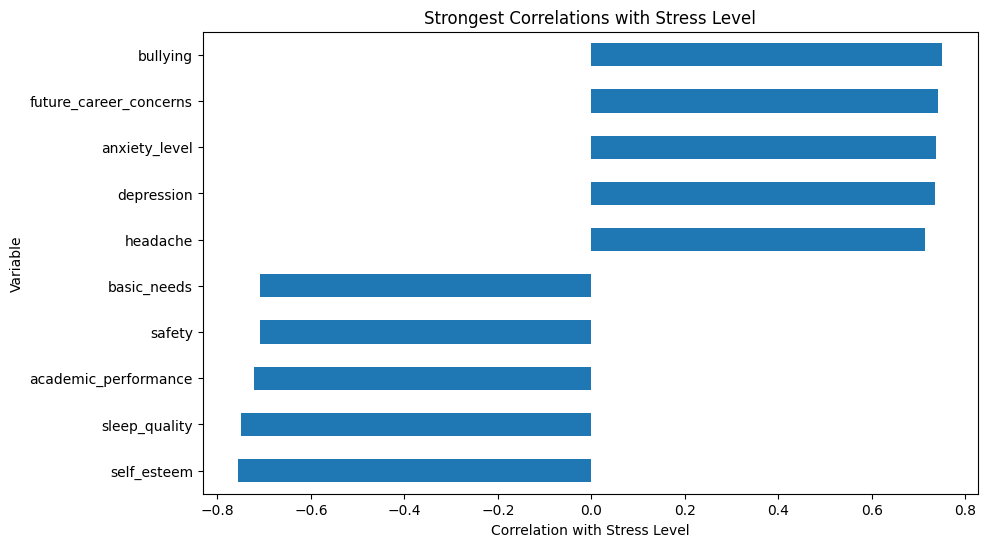

In [ ]:
top_positive = stress_cor.head(5)
top_negative = stress_cor.tail(5)

selected_corr = pd.concat([top_positive, top_negative])

selected_corr.sort_values().plot(
    kind="barh",
    figsize=(10, 6)
)

plt.title("Strongest Correlations with Stress Level")
plt.xlabel("Correlation with Stress Level")
plt.ylabel("Variable")

plt.show()


Stress Level Comparison Across Different Student Factors




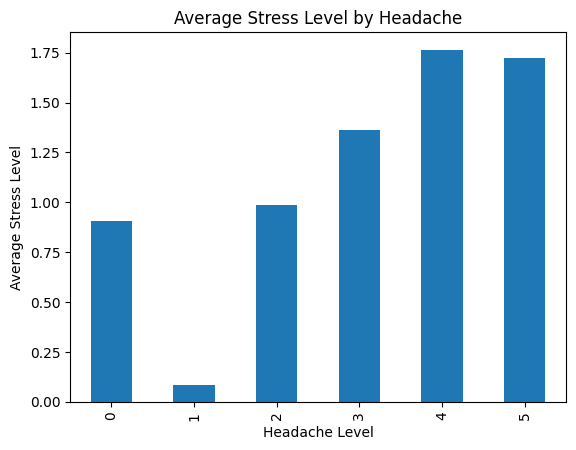

In [ ]:
df1.groupby("headache")["stress_level"].mean().plot(kind="bar")
plt.title("Average Stress Level by Headache")
plt.xlabel("Headache Level")
plt.ylabel("Average Stress Level")
plt.show()

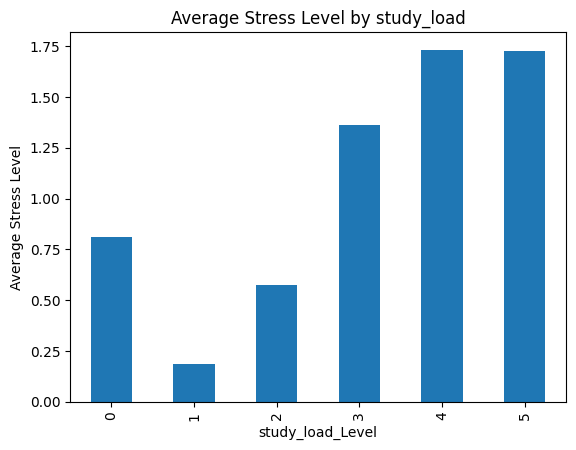

In [ ]:
df1.groupby("study_load")["stress_level"].mean().plot(kind="bar")
plt.title("Average Stress Level by study_load")
plt.xlabel("study_load_Level")
plt.ylabel("Average Stress Level")
plt.show()

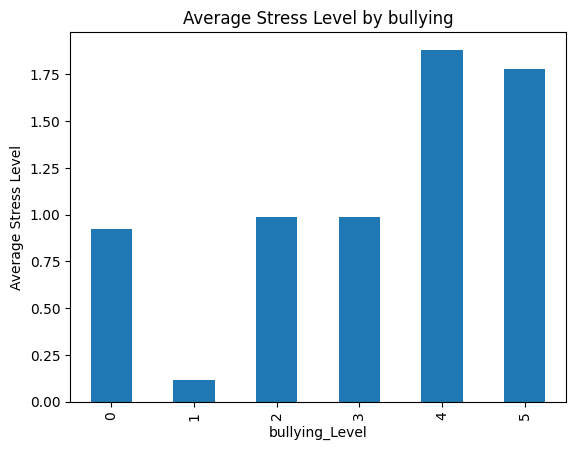

In [ ]:
df1.groupby("bullying")["stress_level"].mean().plot(kind="bar")
plt.title("Average Stress Level by bullying")
plt.xlabel("bullying_Level")
plt.ylabel("Average Stress Level")
plt.show()

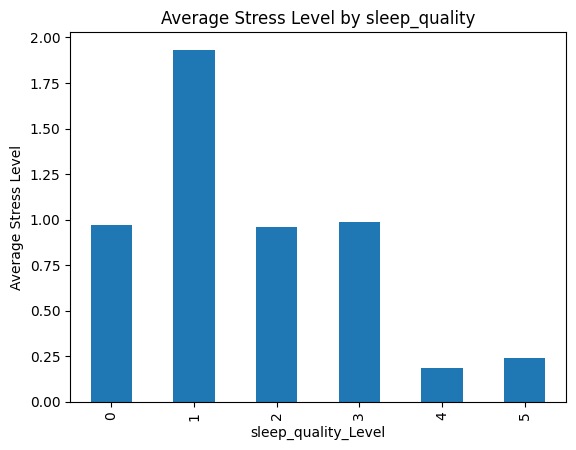

In [ ]:
df1.groupby("sleep_quality")["stress_level"].mean().plot(kind="bar")
plt.title("Average Stress Level by sleep_quality")
plt.xlabel("sleep_quality_Level")
plt.ylabel("Average Stress Level")
plt.show()

In [ ]:
result = df1.groupby(
    ["bullying", "sleep_quality"]
)["stress_level"].mean().reset_index()

result

,bullying,sleep_quality,stress_level
0,0,0,1.000000
1,0,2,0.800000
2,0,3,0.750000
3,0,4,1.000000
4,0,5,1.000000
5,1,0,0.250000
6,1,1,1.222222
7,1,2,0.600000
8,1,3,2.000000
9,1,4,0.050000


In [ ]:
high_bullying_poor_sleep = df1[
    (df1["bullying"] >= 4) &
    (df1["sleep_quality"] <= 2)
]

high_stress = high_bullying_poor_sleep["stress_level"].mean()

In [ ]:
low_bullying_good_sleep = df1[
    (df1["bullying"] <= 2) &
    (df1["sleep_quality"] >= 4)
]

low_stress = low_bullying_good_sleep["stress_level"].mean()

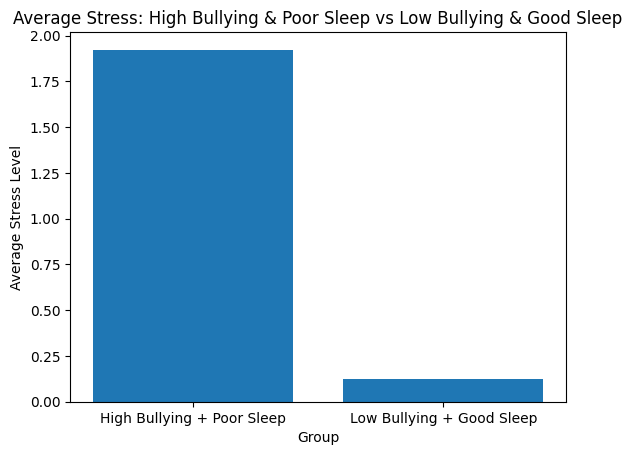

In [ ]:
groups = ["High Bullying + Poor Sleep", "Low Bullying + Good Sleep"]
stress_values = [high_stress, low_stress]

plt.bar(groups, stress_values)

plt.title("Average Stress: High Bullying & Poor Sleep vs Low Bullying & Good Sleep")
plt.xlabel("Group")
plt.ylabel("Average Stress Level")

plt.show()

In [ ]:
result2 = df1.groupby(
    ["anxiety_level", "self_esteem"]
)["stress_level"].mean().reset_index()

result2

,anxiety_level,self_esteem,stress_level
0,0,25,0.0
1,0,26,0.0
2,0,27,0.5
3,0,28,0.0
4,0,30,0.0
...,...,...,...
329,21,19,1.0
330,21,20,2.0
331,21,27,0.0
332,21,28,1.0


In [ ]:
high_anxiety_low_self = df1[
    (df1["anxiety_level"] >= 4) &
    (df1["self_esteem"] <= 2)
]

high_anxiety_stress = high_anxiety_low_self["stress_level"].mean()

In [ ]:
low_anxiety_high_self = df1[
    (df1["anxiety_level"] <= 2) &
    (df1["self_esteem"] >= 4)
]

low_anxiety_stress = low_anxiety_high_self["stress_level"].mean()

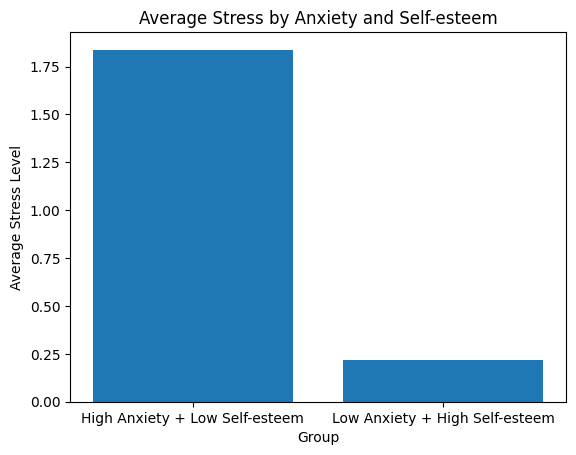

In [ ]:
groups = ["High Anxiety + Low Self-esteem",
          "Low Anxiety + High Self-esteem"]

stress_values = [high_anxiety_stress, low_anxiety_stress]

plt.bar(groups, stress_values)

plt.title("Average Stress by Anxiety and Self-esteem")
plt.xlabel("Group")
plt.ylabel("Average Stress Level")

plt.show()

In [ ]:
df1["risk_score"] = (
    (df1["anxiety_level"] >= 4).astype(int)
    + (df1["bullying"] >= 4).astype(int)
    + (df1["study_load"] >= 4).astype(int)
    + (df1["future_career_concerns"] >= 4).astype(int)
    + (df1["sleep_quality"] <= 2).astype(int)
)

In [ ]:
df1["risk_score"].value_counts().sort_index()

,count
risk_score,
0,137
1,346
2,239
3,53
4,126
5,199


In [ ]:
risk_stress = df1.groupby("risk_score")["stress_level"].mean()

risk_stress

,stress_level
risk_score,
0,0.036496
1,0.526012
2,0.979079
3,1.000000
4,1.793651
5,1.989950


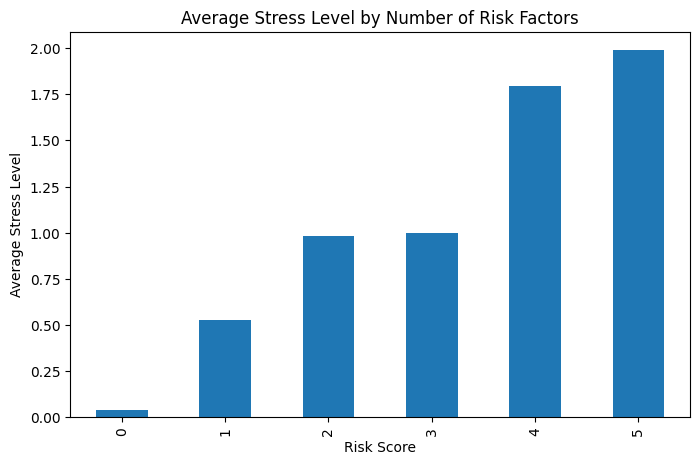

In [ ]:
risk_stress.plot(kind="bar", figsize=(8,5))

plt.title("Average Stress Level by Number of Risk Factors")
plt.xlabel("Risk Score")
plt.ylabel("Average Stress Level")

plt.show()

In [ ]:
high_stress_group = df1[df1["stress_level"] == 2]

low_stress_group = df1[df1["stress_level"] == 0]

In [ ]:
profile_vars = [
    "anxiety_level",
    "self_esteem",
    "sleep_quality",
    "bullying",
    "headache",
    "future_career_concerns",
    "academic_performance",
    "social_support"
]

In [ ]:
profile_comparison = df1.groupby("stress_level")[profile_vars].mean()

profile_comparison

,anxiety_level,self_esteem,sleep_quality,bullying,headache,future_career_concerns,academic_performance,social_support
stress_level,,,,,,,,
0,5.431635,25.252011,4.126005,1.254692,1.313673,1.335121,4.142091,2.541555
1,11.430168,19.262570,2.530726,2.555866,2.460894,2.522346,2.491620,2.178771
2,16.401084,8.780488,1.303523,4.054201,3.761518,4.100271,1.661247,0.926829


In [ ]:
profile = profile_comparison.loc[[0, 2]]

profile_normalized = (profile - profile.min()) / (profile.max() - profile.min())

profile_normalized

,anxiety_level,self_esteem,sleep_quality,bullying,headache,future_career_concerns,academic_performance,social_support
stress_level,,,,,,,,
0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0
2,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0


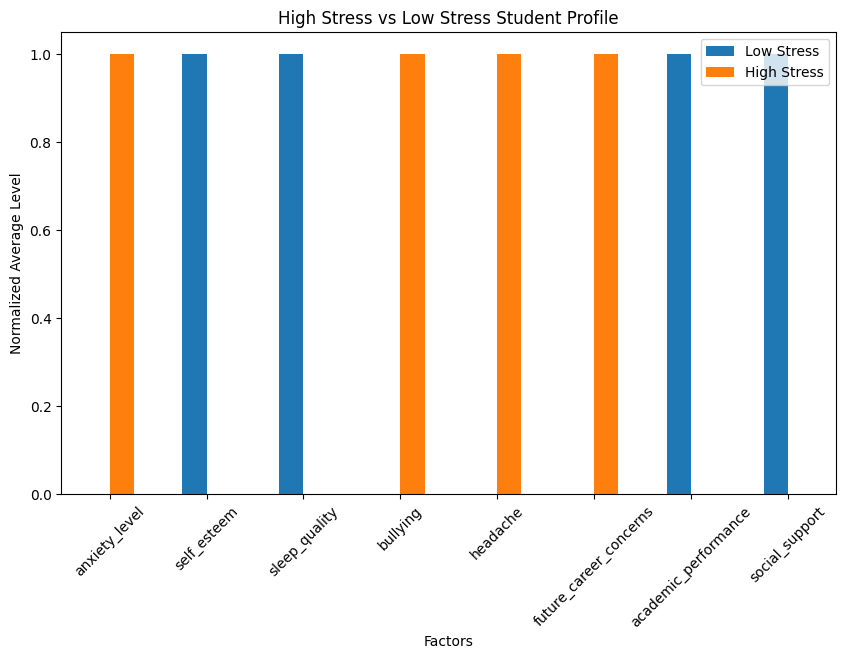

In [ ]:
profile_normalized.T.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("High Stress vs Low Stress Student Profile")
plt.xlabel("Factors")
plt.ylabel("Normalized Average Level")

plt.xticks(rotation=45)
plt.legend(["Low Stress", "High Stress"])

plt.show()

In [ ]:
df2.head(10)

,Gender,Age,Have you recently experienced stress in your life?,Have you noticed a rapid heartbeat or palpitations?,Have you been dealing with anxiety or tension recently?,Do you face any sleep problems or difficulties falling asleep?,Have you been getting headaches more often than usual?,Do you get irritated easily?,Do you have trouble concentrating on your academic tasks?,Have you been feeling sadness or low mood?,...,Are you facing any difficulties with your professors or instructors?,Is your working environment unpleasant or stressful?,Do you struggle to find time for relaxation and leisure activities?,Is your hostel or home environment causing you difficulties?,Do you lack confidence in your academic performance?,Do you lack confidence in your choice of academic subjects?,Academic and extracurricular activities conflicting for you?,Do you attend classes regularly?,Have you gained/lost weight?,Which type of stress do you primarily experience?
0,Female,20.0,3,4,2,5,2,1,2,2,...,3,1,4,1,2,1,3,1,2,Eustress (Positive Stress) - Stress that motiv...
1,Female,20.0,2,3,2,1,1,1,4,2,...,3,2,1,1,3,2,1,4,2,Eustress (Positive Stress) - Stress that motiv...
2,Female,20.0,5,4,2,2,3,4,2,3,...,2,2,2,1,4,1,1,2,1,Eustress (Positive Stress) - Stress that motiv...
3,Male,20.0,3,4,3,2,3,4,3,5,...,1,1,2,1,2,1,1,5,3,Eustress (Positive Stress) - Stress that motiv...
4,Female,20.0,3,3,3,2,4,4,4,4,...,2,3,1,2,2,4,2,2,2,Eustress (Positive Stress) - Stress that motiv...
5,Female,20.0,3,4,3,2,3,4,1,3,...,2,3,1,2,3,2,4,4,4,Eustress (Positive Stress) - Stress that motiv...
6,Female,20.0,2,2,1,4,3,4,1,3,...,4,4,2,3,4,3,3,3,2,Eustress (Positive Stress) - Stress that motiv...
7,Female,20.0,5,5,5,2,2,1,1,2,...,1,4,2,4,3,1,1,1,5,Eustress (Positive Stress) - Stress that motiv...
8,Female,20.0,3,2,1,5,5,1,1,2,...,4,4,2,4,4,3,1,5,1,Eustress (Positive Stress) - Stress that motiv...
9,Female,21.0,3,4,2,1,2,1,2,3,...,1,1,1,1,1,1,2,4,2,No Stress - Currently experiencing minimal to ...


In [ ]:
df2.columns

Index(['Gender', 'Age', 'Have you recently experienced stress in your life?',
       'Have you noticed a rapid heartbeat or palpitations?',
       'Have you been dealing with anxiety or tension recently?',
       'Do you face any sleep problems or difficulties falling asleep?',
       'Have you been getting headaches more often than usual?',
       'Do you get irritated easily?',
       'Do you have trouble concentrating on your academic tasks?',
       'Have you been feeling sadness or low mood?',
       'Have you been experiencing any illness or health issues?',
       'Do you often feel lonely or isolated?',
       'Do you feel overwhelmed with your academic workload?',
       'Are you in competition with your peers, and does it affect you?',
       'Do you find that your relationship often causes you stress?',
       'Are you facing any difficulties with your professors or instructors?',
       'Is your working environment unpleasant or stressful?',
       'Do you struggle to find 

In [ ]:
corr2 = df2.corr(numeric_only=True)

stress_cor2 = corr2["Have you recently experienced stress in your life?"]

stress_cor2 = stress_cor2.drop("Have you recently experienced stress in your life?")

stress_cor2 = stress_cor2.sort_values(ascending=False)

stress_cor2

,Have you recently experienced stress in your life?
Have you noticed a rapid heartbeat or palpitations?,0.442731
Have you been dealing with anxiety or tension recently?,0.233491
Academic and extracurricular activities conflicting for you?,0.227115
Have you gained/lost weight?,0.164272
Do you face any sleep problems or difficulties falling asleep?,0.126553
Do you lack confidence in your choice of academic subjects?,0.114316
Age,0.106983
Have you been experiencing any illness or health issues?,0.077135
"Are you in competition with your peers, and does it affect you?",0.068340
Have you been feeling sadness or low mood?,0.065068


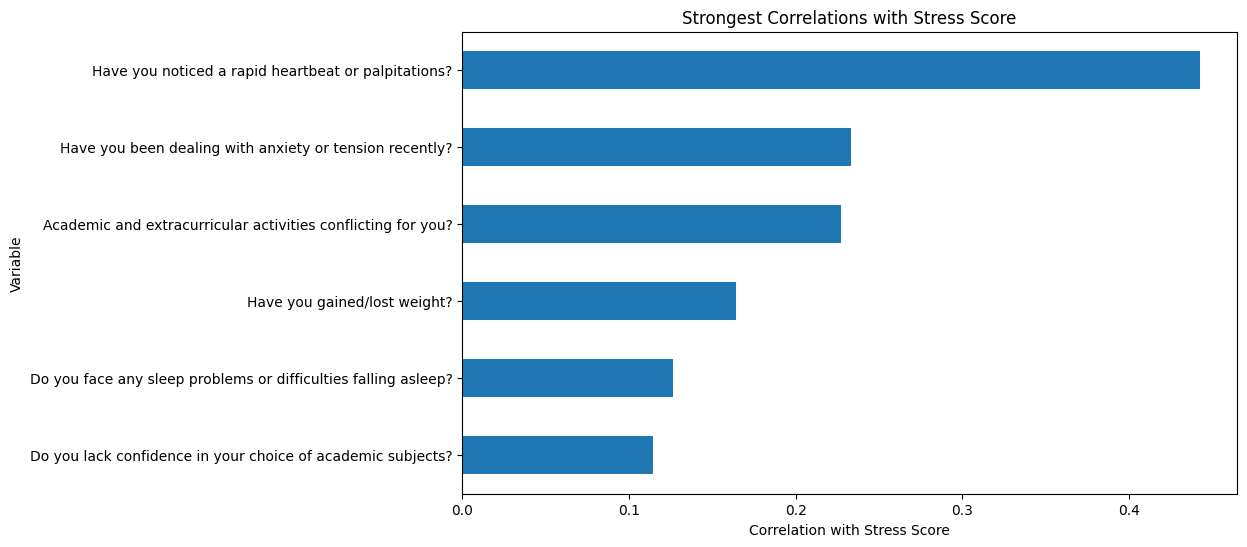

In [ ]:
top_corr2 = stress_cor2.head(6)

top_corr2.sort_values().plot(
    kind="barh",
    figsize=(10, 6)
)

plt.title("Strongest Correlations with Stress Score")
plt.xlabel("Correlation with Stress Score")
plt.ylabel("Variable")

plt.show()

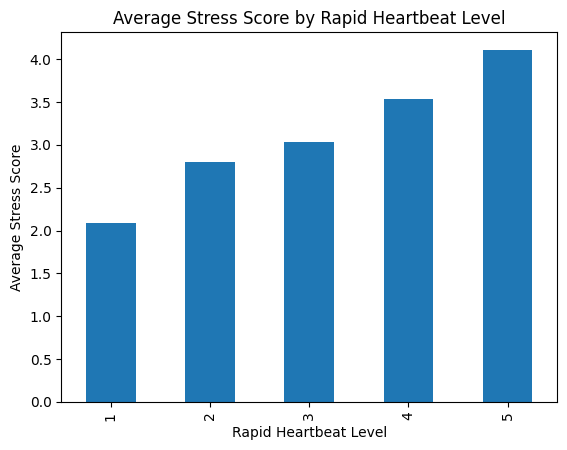

In [ ]:
df2.groupby(
    "Have you noticed a rapid heartbeat or palpitations?"
)["Have you recently experienced stress in your life?"].mean().plot(
    kind="bar"
)

plt.title("Average Stress Score by Rapid Heartbeat Level")
plt.xlabel("Rapid Heartbeat Level")
plt.ylabel("Average Stress Score")

plt.show()

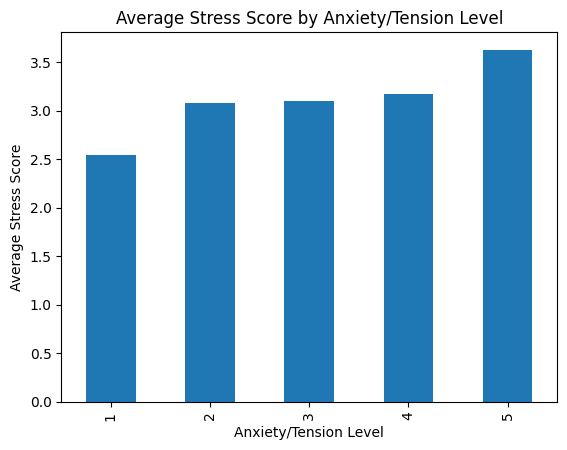

In [ ]:
df2.groupby(
    "Have you been dealing with anxiety or tension recently?"
)["Have you recently experienced stress in your life?"].mean().plot(
    kind="bar"
)

plt.title("Average Stress Score by Anxiety/Tension Level")
plt.xlabel("Anxiety/Tension Level")
plt.ylabel("Average Stress Score")

plt.show()

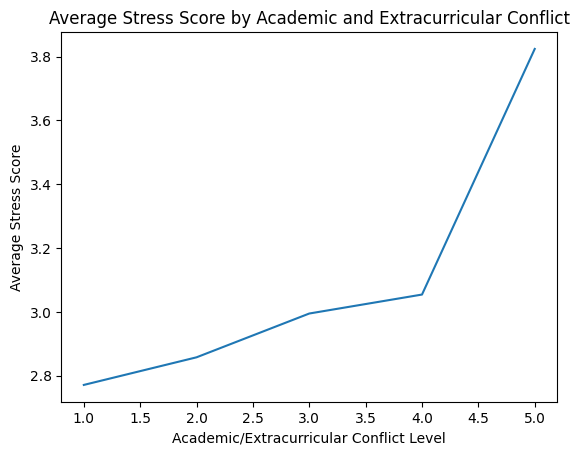

In [ ]:
df2.groupby(
    "Academic and extracurricular activities conflicting for you?"
)["Have you recently experienced stress in your life?"].mean().plot(
    kind="line"
)

plt.title("Average Stress Score by Academic and Extracurricular Conflict")
plt.xlabel("Academic/Extracurricular Conflict Level")
plt.ylabel("Average Stress Score")

plt.show()

In [ ]:
high_stress = df2[
    df2["Have you recently experienced stress in your life?"] >= 4
]

low_stress = df2[
    df2["Have you recently experienced stress in your life?"] <= 2
]

In [ ]:
symptoms = [
    "Have you noticed a rapid heartbeat or palpitations?",
    "Have you been dealing with anxiety or tension recently?",
    "Do you face any sleep problems or difficulties falling asleep?",
    "Have you been getting headaches more often than usual?",
    "Do you get irritated easily?",
    "Do you have trouble concentrating on your academic tasks?",
    "Have you been feeling sadness or low mood?"
]

In [ ]:
symptom_comparison = pd.DataFrame({
    "High Stress": high_stress[symptoms].mean(),
    "Low Stress": low_stress[symptoms].mean()
})

symptom_comparison

,High Stress,Low Stress
Have you noticed a rapid heartbeat or palpitations?,3.294964,2.149466
Have you been dealing with anxiety or tension recently?,2.888489,2.263345
Do you face any sleep problems or difficulties falling asleep?,3.021583,2.644128
Have you been getting headaches more often than usual?,2.651079,2.587189
Do you get irritated easily?,2.701439,2.633452
Do you have trouble concentrating on your academic tasks?,2.812950,2.629893
Have you been feeling sadness or low mood?,2.679856,2.437722


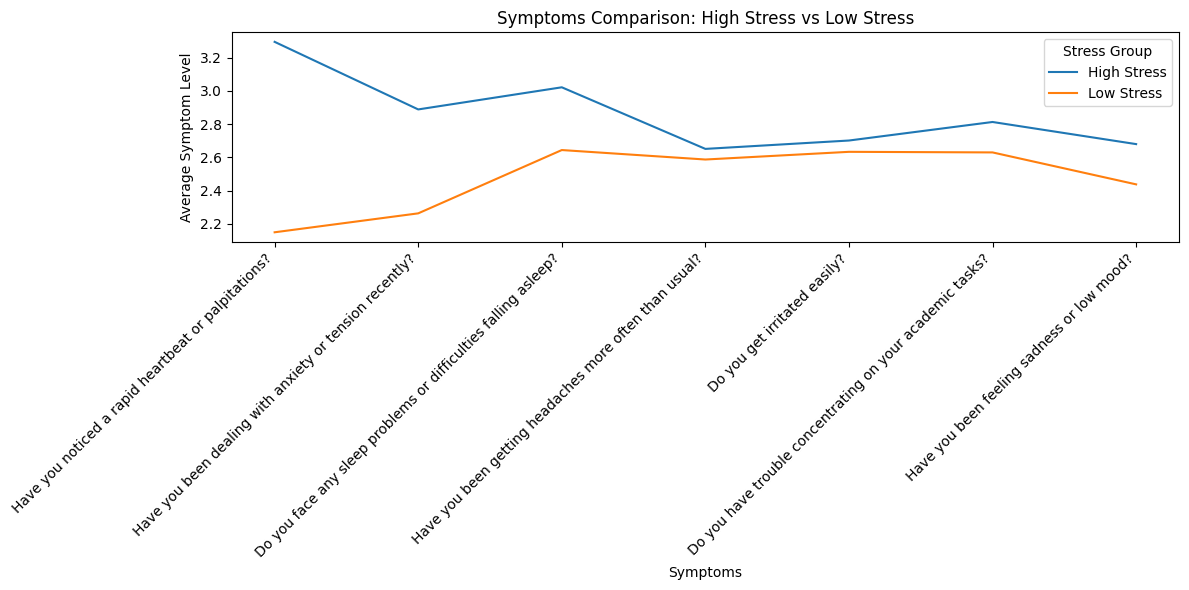

In [ ]:
symptom_comparison.plot(kind="line", figsize=(12, 6))

plt.title("Symptoms Comparison: High Stress vs Low Stress")
plt.xlabel("Symptoms")
plt.ylabel("Average Symptom Level")
plt.xticks(rotation=45, ha="right")

plt.legend(title="Stress Group")
plt.tight_layout()
plt.show()

In [ ]:
stress_type_counts = df2[
    "Which type of stress do you primarily experience?"
].value_counts()

stress_type_counts

,count
Which type of stress do you primarily experience?,
Eustress (Positive Stress) - Stress that motivates and enhances performance.,745
No Stress - Currently experiencing minimal to no stress.,42
Distress (Negative Stress) - Stress that causes anxiety and impairs well-being.,29


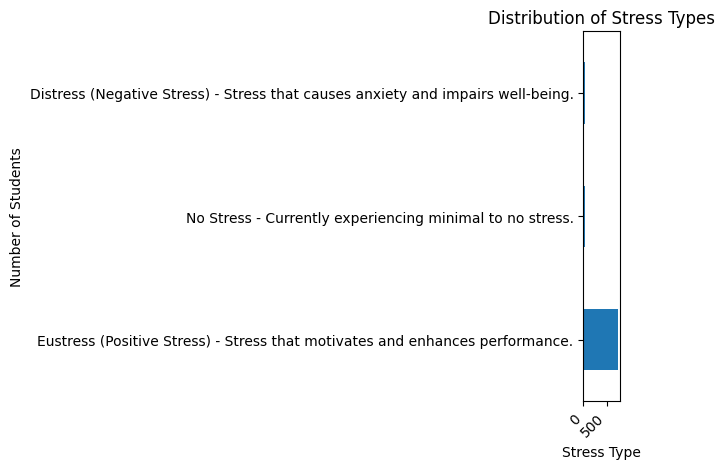

In [ ]:
stress_type_counts.plot(kind="barh")

plt.title("Distribution of Stress Types")
plt.xlabel("Stress Type")
plt.ylabel("Number of Students")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [ ]:
from google.colab import files

files.download("/content/StressLevelDataset.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
files.download("/content/Stress_Dataset.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>